In [1]:
import sys
import os
import requests

import torch
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image

# # check whether run in Colab
# if 'google.colab' in sys.modules:
#     print('Running in Colab.')
#     !pip3 install timm==0.4.5  # 0.3.2 does not work in Colab
#     !git clone https://github.com/facebookresearch/mae.git
#     sys.path.append('./mae')
# else:
#     sys.path.append('..')
import models_mae
import models_mae_cnn
import cv2

In [2]:
import os

img_list_val = []
data_dir = '.\\Datasets\\Dataset_L'

# List all files in the directory
for file_name in os.listdir(data_dir):
    # Create the full path for each image and add it to the list
    imagePath = os.path.join(data_dir, file_name)
    img_list_val.append(imagePath)

img_list_val

img_list_val_labels = []


In [3]:
def load_img_gray(path, size=224, mean=np.array([0.485, 0.456, 0.406]), std=np.array([0.229, 0.224, 0.225])):
    img = Image.open(path).convert('RGB')
    img = img.resize((size, size))
    img = np.array(img) / 255.
    assert img.shape == (size, size, 3)
    # normalize by ImageNet mean and std
    img = img - mean
    img = img / std
    return img


chestxray_mean = np.array([0.5095, 0.5095, 0.5095])
chestxray_std = np.array([0.2798, 0.2798, 0.2798])

def show_image(image, title='', mean=chestxray_mean, std=chestxray_std):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    plt.imshow(torch.clip((image * std + mean) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
#     print(title,'min:', image.min().item(),'max:', image.max().item())
#     print(title,'mean:', image.mean().item(),'std:',  image.std().item())
    return torch.clip((image * std + mean) * 255, 0, 255).numpy().astype(np.uint8)

In [4]:
def prepare_model(chkpt_dir, arch='mae_vit_large_patch16',heatmap=None, mask_strategy='random'):
    # build model
    model = getattr(models_mae, arch)(heatmap=heatmap, mask_strategy=mask_strategy)
    # load model
    checkpoint = torch.load(chkpt_dir, map_location='cpu')
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    return model

def pick_best_image_over_runs(img, model, mask_ratio=0.75, run=1):
    # run MAE
    lowest_loss = 100
    for seed in range(run):
        x = torch.tensor(img)

        # make it a batch-like
        x = x.unsqueeze(dim=0)
        x = torch.einsum('nhwc->nchw', x)
        torch.manual_seed(seed)
        loss, y, mask = model(x.float(), mask_ratio=mask_ratio)
        if loss.detach().numpy().item() < lowest_loss:
            lowest_loss = loss.detach().numpy().item()
            best_seed = seed
        print(loss.detach().numpy())
    
    x = torch.tensor(img)
    torch.manual_seed(best_seed)
    x = x.unsqueeze(dim=0)
    x = torch.einsum('nhwc->nchw', x)
    loss, y, mask = model(x.float(), mask_ratio=mask_ratio)
    print(loss.detach().numpy())
    y = model.unpatchify(y)
    y = torch.einsum('nchw->nhwc', y).detach().cpu()

    # visualize the mask
    mask = mask.detach()
    mask = mask.unsqueeze(-1).repeat(1, 1, model.patch_embed.patch_size[0]**2 *3)  # (N, H*W, p*p*3)
    mask = model.unpatchify(mask)  # 1 is removing, 0 is keeping
    mask = torch.einsum('nchw->nhwc', mask).detach().cpu()

    x = torch.einsum('nchw->nhwc', x)

    # masked image
    im_masked = x * (1 - mask)

    # MAE reconstruction pasted with visible patches
    im_paste = x * (1 - mask) + y * mask

    # make the plt figure larger
    plt.rcParams['figure.figsize'] = [24, 24]

    plt.subplot(1, 5, 1)
    img_original = show_image(x[0], "original")

    plt.subplot(1, 5, 2)
    img_masked = show_image(im_masked[0], "masked")

    plt.subplot(1, 5, 3)
    img_reconstruction = show_image(y[0], "reconstruction")
    plt.subplot(1, 5, 4)
    img_paste = show_image(im_paste[0], "reconstruction + visible")
    plt.subplot(1, 5, 5)
    show_image(torch.abs(x[0] - im_paste[0]), "raw - (reconstruction + visible)")
    plt.show()
    return [img_original, img_masked, img_paste]


# img_from_val_path = 'data/nih_chestxray/00000087_000.png'
chkpt_dir = './models/0.75/models/0.75/checkpoint-99.pth'
model_mae = prepare_model(chkpt_dir, 'mae_vit_small_patch16_dec512d2b', heatmap=None)
i = 3
for mask_ratio_percentage in [75, 80, 85, 90]:
    img_from_val_path = img_list_val[i]
    print(img_list_val_labels[i])
    img_from_val = load_img_gray(img_from_val_path, size=224, mean=chestxray_mean, std=chestxray_std)
    img_original, img_masked, img_paste = pick_best_image_over_runs(img_from_val, model_mae, mask_ratio=0.01 * mask_ratio_percentage, run=1)

    plt.imsave(f'figures/vit-s_masked_input_mask{mask_ratio_percentage}_img{i}.png', img_masked)
    plt.imsave(f'figures/vit-s_reconstruction_mask{mask_ratio_percentage}_img{i}.png', img_paste)


AttributeError: module 'models_mae' has no attribute 'densenet121-fbdb23505'

In [4]:
from matplotlib.pyplot import cm

<All keys matched successfully>
0.6632756
0.6632756
torch.Size([1, 3, 224, 224])
torch.Size([1, 224, 224, 3])
torch.Size([1, 3, 224, 224])


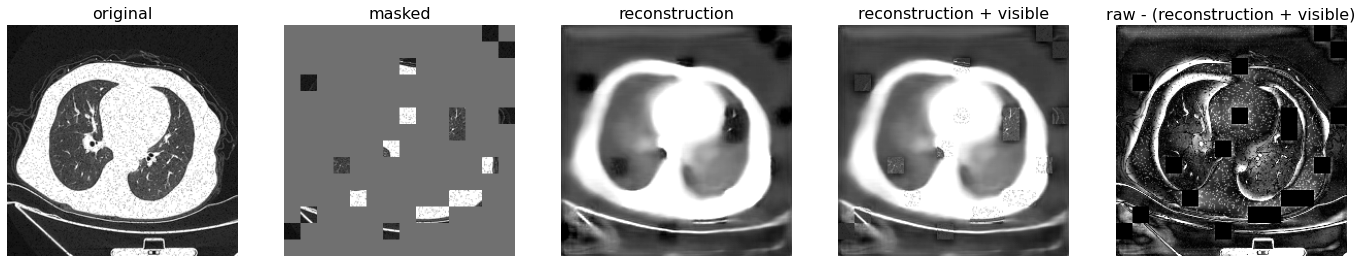

(224, 224)


In [5]:
def prepare_model_cnn(chkpt_dir, model_arch='Unet', encoder_model='densenet121'):
    # build model
    model = models_mae_cnn.MaskedAutoencoderCNN(img_size=224, patch_size=16, model_arch='Unet', encoder_name=encoder_model)
    # load model
    checkpoint = torch.load(chkpt_dir, map_location='cpu')
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    return model

def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

def show_image(image, title='', mean=chestxray_mean, std=chestxray_std):
    # image is [H, W, 3]
    assert image.shape[2] == 3

    plt.imshow(torch.clip((image * std + mean) * 255, 0, 255).int()[:,:,0], cmap='gray')
    plt.title(title, fontsize=16)
    plt.axis('off')
#     print(title,'min:', image.min().item(),'max:', image.max().item())
#     print(title,'mean:', image.mean().item(),'std:',  image.std().item())
    return torch.clip((image * std + mean) * 255, 0, 255).numpy().astype(np.uint8)[:,:,0]


def pick_best_image_over_runs(img, model, mask_ratio=0.75, run=1):


    # run MAE
    lowest_loss = 100
    for seed in range(run):
        x = torch.tensor(img)

        # make it a batch-like
        x = x.unsqueeze(dim=0)
        x = torch.einsum('nhwc->nchw', x)
        torch.manual_seed(seed)
        loss, y, mask = model(x.float(), mask_ratio=mask_ratio)
        if loss.detach().numpy().item() < lowest_loss:
            lowest_loss = loss.detach().numpy().item()
            best_seed = seed
        print(loss.detach().numpy())
    
    x = torch.tensor(img)
    torch.manual_seed(best_seed)
    x = x.unsqueeze(dim=0)
    x = torch.einsum('nhwc->nchw', x)
    loss, y, mask = model(x.float(), mask_ratio=mask_ratio)
    print(loss.detach().numpy())
    print(x.shape)
    mask = mask.unsqueeze(-1).repeat(1, 1, 16**2 *3)  # (N, H*W, p*p*3)
    mask = model.unpatchify(mask)  # 1 is removing, 0 is keeping
    mask = torch.einsum('nchw->nhwc', mask).detach().cpu()
    print(mask.shape)
    print(y.shape)
#     y = model.unpatchify(y)
    y = torch.einsum('nchw->nhwc', y).detach().cpu()

    # visualize the mask
    mask = mask.detach()
#     x_masked = self.unpatchify(x * (1 - mask.unsqueeze(-1)))

#     mask = mask.unsqueeze(-1).repeat(1, 1, model.patch_embed.patch_size[0]**2 *3)  # (N, H*W, p*p*3)
#     mask = model.unpatchify(mask)  # 1 is removing, 0 is keeping
#     mask = torch.einsum('nchw->nhwc', mask).detach().cpu()

    x = torch.einsum('nchw->nhwc', x)

    # masked image
    im_masked = x * (1 - mask)

    # MAE reconstruction pasted with visible patches
    im_paste = x * (1 - mask) + y * mask

    # make the plt figure larger
    plt.rcParams['figure.figsize'] = [24, 24]

    plt.subplot(1, 5, 1)
    img_original = show_image(x[0], "original")

    plt.subplot(1, 5, 2)
    img_masked = show_image(im_masked[0], "masked")

    plt.subplot(1, 5, 3)
    img_reconstruction = show_image(y[0], "reconstruction")
    plt.subplot(1, 5, 4)
    img_paste = show_image(im_paste[0], "reconstruction + visible")
    plt.subplot(1, 5, 5)
    show_image(torch.abs(x[0] - im_paste[0]), "raw - (reconstruction + visible)")
    plt.show()
    return [img_original, img_masked, img_paste]


# img_from_val_path = 'data/nih_chestxray/00000087_000.png'
chkpt_dir = './models/0.90/checkpoint-99-mae-pretrain-90.pth'
model_mae = prepare_model_cnn(chkpt_dir, model_arch='Unet', encoder_model='densenet121')
i = 3
for mask_ratio_percentage in [90]:
    img_from_val_path = img_list_val[i]
    img_from_val = load_img_gray(img_from_val_path, size=224, mean=chestxray_mean, std=chestxray_std)
    img_original, img_masked, img_paste = pick_best_image_over_runs(img_from_val, model_mae, mask_ratio=0.01 * mask_ratio_percentage, run=1)
    print(img_masked.shape)
    plt.imsave(f'figures/densenet121_masked_input_mask{mask_ratio_percentage}_img{i}.png', img_masked, cmap=cm.gray)
    plt.imsave(f'figures/densenet121_reconstruction_mask{mask_ratio_percentage}_img{i}.png', img_paste, cmap=cm.gray)

# plt.imshow(result_img)
#     plt.imsave(f'figures/reconstruction_mask75_img{i}.png', result_img)
    
# chkpt_dir = './work_dirs/pretrain_exp43_chestxray_vit_small_200e_224_mask80_SA_mean_fixed_RRC_e1/checkpoint-199.pth'
# model_mae = prepare_model(chkpt_dir, 'mae_vit_small_patch16_dec512d2b', heatmap=None, mask_strategy='self_attention_mean')
# for i in range(1,5):
#     img_from_val_path = img_list_val[i]
#     print(img_list_val_labels[i])
#     img_from_val = load_img_gray(img_from_val_path, size=224, mean=chestxray_mean, std=chestxray_std)
#     result_img = pick_best_image_over_runs(img_from_val, model_mae, mask_ratio=0.80, run=5)
#     plt.imsave(f'figures/reconstruction_mask80_img{i}.png', result_img)


# chkpt_dir = './work_dirs/pretrain_exp42_chestxray_vit_small_200e_224_mask85_SA_mean_fixed_RRC_e1/checkpoint-199.pth'
# model_mae = prepare_model(chkpt_dir, 'mae_vit_small_patch16_dec512d2b', heatmap=None, mask_strategy='self_attention_mean')
# for i in range(1,5):
#     img_from_val_path = img_list_val[i]
#     print(img_list_val_labels[i])
#     img_from_val = load_img_gray(img_from_val_path, size=224, mean=chestxray_mean, std=chestxray_std)
#     result_img = pick_best_image_over_runs(img_from_val, model_mae, mask_ratio=0.85, run=5)
#     plt.imsave(f'figures/reconstruction_mask85_img{i}.png', result_img)



# chkpt_dir = './work_dirs/pretrain_exp33_chestxray_vit_small_200e_224_mask90_SA_mean_fixed_RRC_e1/checkpoint-199.pth'
# model_mae = prepare_model(chkpt_dir, 'mae_vit_small_patch16_dec512d2b', heatmap=None, mask_strategy='self_attention_mean')
# for i in range(1,5):
#     img_from_val_path = img_list_val[i]
#     print(img_list_val_labels[i])
#     img_from_val = load_img_gray(img_from_val_path, size=224, mean=chestxray_mean, std=chestxray_std)
#     result_img = pick_best_image_over_runs(img_from_val, model_mae, mask_ratio=0.90, run=5)
#     plt.imshow(result_img)
#     plt.imsave(f'figures/reconstruction_mask90_img{i}.png', result_img)

Evaluating checkpoint: ./models/0.75/checkpoint-99-mae-pretrain-75.pth


Processing Images: 100%|██████████| 40000/40000 [1:17:06<00:00,  8.65it/s]


Checkpoint ./models/0.75/checkpoint-99-mae-pretrain-75.pth - Average Reconstruction Loss: 0.5339
Evaluating checkpoint: ./models/0.80/checkpoint-99-mae-pretrain-80.pth


Processing Images: 100%|██████████| 40000/40000 [1:16:18<00:00,  8.74it/s]


Checkpoint ./models/0.80/checkpoint-99-mae-pretrain-80.pth - Average Reconstruction Loss: 0.5170
Evaluating checkpoint: ./models/0.85/checkpoint-99-mae-pretrain-85.pth


...

Processing Images: 100%|██████████| 40000/40000 [1:17:08<00:00,  8.64it/s]


Checkpoint ./models/0.90/checkpoint-99-mae-pretrain-90.pth - Average Reconstruction Loss: 0.4124
Evaluating checkpoint: ./models/0.95/checkpoint-99-mae-pretrain-95.pth


Processing Images: 100%|██████████| 40000/40000 [1:18:44<00:00,  8.47it/s]


Checkpoint ./models/0.95/checkpoint-99-mae-pretrain-95.pth - Average Reconstruction Loss: 0.4961

Best Checkpoint: ./models/0.90/checkpoint-99-mae-pretrain-90.pth with Lowest Average Loss: 0.4124


TypeError: clip() received an invalid combination of arguments - got (numpy.ndarray, int, int), but expected one of:
 * (Tensor input, Tensor min, Tensor max, *, Tensor out)
 * (Tensor input, Number min, Number max, *, Tensor out)


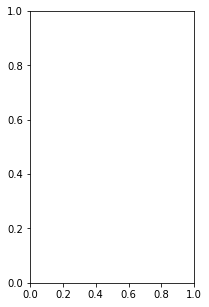

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import models_mae_cnn
import os
from tqdm import tqdm

# Define checkpoints and dataset directory
checkpoints = [
    './models/0.75/checkpoint-99-mae-pretrain-75.pth',
    './models/0.80/checkpoint-99-mae-pretrain-80.pth',
    './models/0.85/checkpoint-99-mae-pretrain-85.pth',
    './models/0.90/checkpoint-99-mae-pretrain-90.pth',
    './models/0.95/checkpoint-99-mae-pretrain-95.pth'
]
data_dir = './Datasets/Dataset_L'
img_list_val = [os.path.join(data_dir, file_name) for file_name in os.listdir(data_dir)]

chestxray_mean = np.array([0.485, 0.456, 0.406])
chestxray_std = np.array([0.229, 0.224, 0.225])

# Image loading and display functions
def load_img_gray(path, size=224, mean=chestxray_mean, std=chestxray_std):
    img = Image.open(path).convert('RGB')
    img = img.resize((size, size))
    img = np.array(img) / 255.
    img = (img - mean) / std
    return img

def show_image(image, title='', mean=chestxray_mean, std=chestxray_std):
    plt.imshow(torch.clip((image * std + mean) * 255, 0, 255).int()[:, :, 0], cmap='gray')
    plt.title(title, fontsize=16)
    plt.axis('off')

# Model preparation function
def prepare_model_cnn(chkpt_dir, model_arch='Unet', encoder_model='densenet121'):
    model = models_mae_cnn.MaskedAutoencoderCNN(img_size=224, patch_size=16, model_arch=model_arch, encoder_name=encoder_model)
    checkpoint = torch.load(chkpt_dir, map_location='cuda')
    model.load_state_dict(checkpoint['model'], strict=False)
    return model

# Reconstruction function
def reconstruct_image(model, img, mask_ratio=0.75):
    x = torch.tensor(img).unsqueeze(0).permute(0, 3, 1, 2)
    loss, y, mask = model(x.float(), mask_ratio=mask_ratio)
    y = y.permute(0, 2, 3, 1).squeeze().detach().cpu().numpy()
    return loss.item(), y

# Evaluate each checkpoint across the dataset
best_checkpoint = None
lowest_avg_loss = float('inf')
checkpoint_losses = {}

for chkpt_path in checkpoints:
    print(f"Evaluating checkpoint: {chkpt_path}")
    model = prepare_model_cnn(chkpt_path)
    losses = []

    for img_path in tqdm(img_list_val, desc="Processing Images"):
        img_val = load_img_gray(img_path)
        loss, _ = reconstruct_image(model, img_val, mask_ratio=0.75)
        losses.append(loss)
    
    avg_loss = np.mean(losses)
    checkpoint_losses[chkpt_path] = avg_loss

    # Check if this is the lowest average loss
    if avg_loss < lowest_avg_loss:
        lowest_avg_loss = avg_loss
        best_checkpoint = chkpt_path

    print(f"Checkpoint {chkpt_path} - Average Reconstruction Loss: {avg_loss:.4f}")

print(f"\nBest Checkpoint: {best_checkpoint} with Lowest Average Loss: {lowest_avg_loss:.4f}")

# Optional: Plot reconstruction for the best checkpoint
model = prepare_model_cnn(best_checkpoint)
img_path = img_list_val[0]  # Test on the first image
img_val = load_img_gray(img_path)
loss, reconstruction = reconstruct_image(model, img_val, mask_ratio=0.75)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
show_image(img_val, "Original")
plt.subplot(1, 3, 2)
show_image(reconstruction, f"Reconstructed (Loss: {loss:.4f})")
plt.subplot(1, 3, 3)
show_image(np.abs(img_val - reconstruction), "Difference")
plt.show()
